In [29]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

In [30]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')


train_df = pd.concat([s20,s21,s22,s23,s24])
val_df = s25
# test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
# print(f"Test data shape: {test_df.shape}")
# print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df.head()

Training data shape: (123581, 1690)
Training date range: 2019-10-23 to 2024-04-14
Validation data shape: (26264, 1683)
Validation date range: 2024-10-23 to 2025-04-13


Unnamed: 0      PLAYER_NAME  PLAYER_ID    MATCHUP TEAM_ABBREVIATION  \
0           0         Alex Len     203458  ATL @ DET               ATL   
1           1   Bruno Fernando    1628981  ATL @ DET               ATL   
2           2      Cam Reddish    1629629  ATL @ DET               ATL   
3           3  De'Andre Hunter    1629631  ATL @ DET               ATL   
4           4  DeAndre' Bembry    1627761  ATL @ DET               ATL   

      TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID   GAME_DATE WL  PTS  AST  \
0  1610612737              DET          0  21900014  2019-10-24  W    4    1   
1  1610612737              DET          0  21900014  2019-10-24  W    7    2   
2  1610612737              DET          0  21900014  2019-10-24  W    1    1   
3  1610612737              DET          0  21900014  2019-10-24  W   14    0   
4  1610612737              DET          0  21900014  2019-10-24  W    8    3   

   REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  FTM  FTA  FT_PCT  OREB  DREB  \
0    6    1    5   0.200     0     2    0.000    2    2     1.0     2     4   
1    3    3    6   0.500     1     1    1.000    0    0     NaN     1     2   
2    7    0    6   0.000     0     5    0.000    1    2     0.5     1     6   
3    2    5    8   0.625     2     3    0.667    2    2     1.0     0     2   
4    2    4    5   0.800     0     1    0.000    0    0     NaN     1     1   

   STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  POINT_PER_SHOT       EFG  \
0    2    1    1          -1         20.7           0.680  0.200000   
1    0    0    0           7         13.6           1.167  0.583333   
2    1    0    0          11         13.9           0.145  0.000000   
3    0    0    2           9         14.4           1.577  0.750000   
4    2    0    0          11         20.9           1.600  0.800000   

  START_POSITION  COMMENT  OFF_RATING  E_OFF_RATING  DEF_RATING  E_DEF_RATING  \
0              C      NaN        86.5          86.5        88.0          88.0   
1            NaN      NaN       150.0         150.0       129.6         129.6   
2              G      NaN       100.0         100.0        75.0          75.0   
3              F      NaN       110.7         110.7        89.3          89.3   
4            NaN      NaN       130.6         130.6       112.8         112.8   

   NET_RATING  OREB_PCT  DREB_PCT  REB_PCT  AST_PCT  EFG_PCT  AST_TOV  \
0        -1.5     0.080     0.121    0.103    0.067    0.200      1.0   
1        20.4     0.083     0.222    0.143    0.143    0.583      0.0   
2        25.0     0.040     0.240    0.140    0.059    0.000      0.0   
3        21.4     0.000     0.059    0.034    0.000    0.750      0.0   
4        17.8     0.050     0.053    0.051    0.150    0.800      0.0   

   USG_PCT  TS_PCT  E_PACE    PACE    PIE  POSS  PACE_PER40  E_USG_PCT    MIN  \
0    0.123   0.340  102.49  102.49  0.085  52.0       85.41      0.123  23.88   
1    0.194   0.583   91.47   91.47  0.080  28.0       76.22      0.194  14.43   
2    0.137   0.073   98.46   98.46  0.024  44.0       82.05      0.137  21.45   
3    0.177   0.788  105.62  105.62  0.113  56.0       88.02      0.177  25.45   
4    0.091   0.800   97.97   97.97  0.112  49.0       81.64      0.091  23.52   

    SPD  DIST  ORBC  DRBC   RBC  TCHS  SAST  FTAST  PASS  CFGM  CFGA  CFG_PCT  \
0  4.01  1.54   6.0   6.0  12.0  37.0   0.0    0.0  30.0   0.0   2.0    0.000   
1  4.18  1.04   3.0   3.0   6.0  29.0   0.0    0.0  23.0   1.0   4.0    0.250   
2  4.24  1.62   1.0   8.0   9.0  24.0   0.0    0.0  15.0   0.0   2.0    0.000   
3  4.34  1.97   2.0   5.0   7.0  27.0   0.0    0.0  15.0   2.0   3.0    0.667   
4  4.17  1.61   1.0   3.0   4.0  19.0   0.0    0.0  13.0   1.0   2.0    0.500   

   UFGM  UFGA  UFG_PCT  DFGM  DFGA  DFG_PCT  PTS_OFF_TOV  PTS_2ND_CHANCE  \
0   1.0   3.0    0.333   2.0   6.0    0.333          2.0             2.0   
1   2.0   2.0    1.000   3.0   5.0    0.600          0.0             2.0   
2   0.0   4.0    0.000   0.0   0.0    0.000    

In [31]:
top_features = [
    # playerContext (7 features)
    'HOME_GAME',
    'STARTING', 
    'PLAYER_IS_TEAM_STAR',
    'TEAM_STAR_OUT',
    'NUM_USUAL_STARTERS_PRESENT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    
    # playerScoring (21 features)
    'PTS_ROLLING_AVG_40',
    'PTS_ROLLING_AVG_15',
    'FGA_ROLLING_AVG_7',
    'EXPECTED_USAGE_MIN',
    'PTS_ROLLING_AVG_10',
    'PTS_ROLLING_AVG_25',
    'USG_X_POSS',
    'FGA_ROLLING_AVG_10',
    'FGA_ROLLING_AVG_5',
    'FG3A_ROLLING_AVG_5',
    'PTS_WITHOUT_STAR',
    'FG3A_WITHOUT_STAR',
    'PTS_PER_36_WITHOUT_STAR',
    'E_USG_PCT_ROLLING_AVG_5',
    'UFGA_ROLLING_AVG_15',
    'FGA_LAG_1',
    'USG_X_TEAM_OFF',
    'E_USG_PCT_ROLLING_AVG_15',
    'USG_PCT_WITHOUT_STAR',
    'USG_PCT_ROLLING_AVG_15',
    'FGA_ROLLING_AVG_25',
    
    # teamContext (7 features)
    'TEAM_PTS_ROLLING_AVG_5',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_OFF_RATING_ROLLING_AVG_5',
    'TEAM_DEF_RATING_ROLLING_AVG_5',
    'TEAM_AST_ROLLING_AVG_5',
    'TEAM_STAR_OUT_X_USG',
    'TEAM_STAR_OUT_X_PTS',
    
    # playerVsOpp (5 features)
    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'PLAYER_PAINT_X_OPP_PAINT_DEF',
    'PTS_PER_MIN_X_OPP_DEF_RATING',
    'USG_X_OPP_DEF_RATING',
    
    # playerZones (7 features)
    'percentagePointsPaint_AVG_TO_DATE',
    'percentagePointsPaint_ROLLING_AVG_40',
    'FTM_ROLLING_AVG_15',
    'PIE_WITHOUT_STAR',
    'percentagePointsPaint_STD_LAST_40',
    'percentagePoints2pt_ROLLING_AVG_15',
    'FTM_AVG_TO_DATE',
    
    # playerHomeAway (1 feature)
    'PLAYER_AWAY_AVG_percentagePointsPaint_TO_DATE',
    
    # playerMatchup (2 features)
    'PFD_ROLLING_AVG_10',
    'RBC_ROLLING_AVG_40'
]

In [14]:
newFeatures = train_df.columns[train_df.columns.tolist().index('STARTING'):].tolist()
df_subset = train_df[newFeatures]

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

def select_features_xgb_importance(X, y, top_n=150):
    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X, y)
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_features = importance_df.head(top_n)['feature'].tolist()
    return X[top_features], top_features

# Select top 300 features from your newFeatures array
selected_features, top_features = select_features_xgb_importance(
    train_df[newFeatures], 
    train_df['PTS'], 
    top_n=41
)
top_features = [f for f in top_features if f != 'PTS_X_TEAM_TOTAL']
additional_features = ['HOME_GAME', 'PLAYER_DAYS_REST', 'IS_BACK_TO_BACK', 'OPP_DEF_RATING_AVG_TO_DATE', 'TEAM_PACE_AVG_TO_DATE', 'OPP_PACE_AVG_TO_DATE']
top_features = top_features + additional_features

print(f"Selected {len(top_features)} features from your newFeatures array")
print(f"Top 10 most important features:")
for i, feature in enumerate(top_features[:10]):
    print(f"{i+1}. {feature}")

Selected 48 features from your newFeatures array
Top 10 most important features:
1. HOME_GAME
2. PLAYER_DAYS_REST
3. IS_BACK_TO_BACK
4. PLAYER_MISSED_LAST
5. OPP_DEF_RATING_AVG_TO_DATE
6. TEAM_PACE_AVG_TO_DATE
7. OPP_PACE_AVG_TO_DATE
8. PTS_ROLLING_AVG_40
9. PTS_ROLLING_AVG_15
10. FGA_ROLLING_AVG_7


# XGBOOST MODEL

In [32]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=False,
    tune_iters=100
)

print("Validation metrics:", val_metrics)

# test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "PTS", used_cats)
# print("Test metrics:", test_metrics)


Validation metrics: {'RMSE': 5.350732248359381, 'MAE': 4.038862751461323, 'R2': 0.6307141780853271, 'best_iteration': 710}


In [33]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                                 TOP_FEATURES  TOP_IMPORTANCE                    BOTTOM_FEATURES  BOTTOM_IMPORTANCE
                           PTS_ROLLING_AVG_15        0.251011                TEAM_STAR_OUT_X_PTS           0.005026
                           PTS_ROLLING_AVG_25        0.144749            E_USG_PCT_ROLLING_AVG_5           0.004479
                           PTS_ROLLING_AVG_40        0.103263      TEAM_OFF_RATING_ROLLING_AVG_5           0.004475
                           FGA_ROLLING_AVG_10        0.085929       PTS_PER_MIN_X_OPP_DEF_RATING           0.004470
                           EXPECTED_USAGE_MIN        0.052310               USG_X_OPP_DEF_RATING           0.004465
                                     STARTING        0.041832                          FGA_LAG_1           0.003993
                 PLAYER_PAINT_X_OPP_PAINT_DEF        0.039982                     USG_X_TEAM_OFF           0.003888
                           P

In [35]:
joblib.dump(xgbModel, 'Models/xgbPTSModel.pkl')
joblib.dump(top_features, 'Models/topPTSfeatures.pkl')

['Models/topPTSfeatures.pkl']

In [19]:
# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

NameError: name 'residuals_df' is not defined

C:\Users\alexg\AppData\Local\Temp\ipykernel_18684\1302807732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_18684\1302807732.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


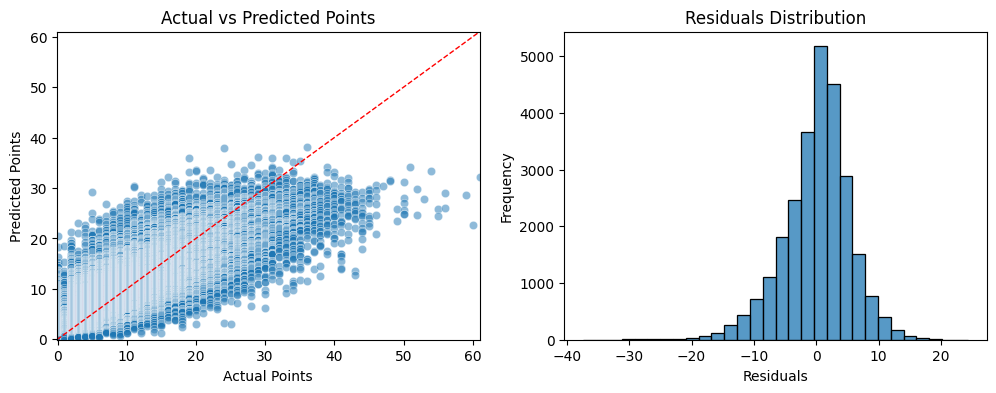

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

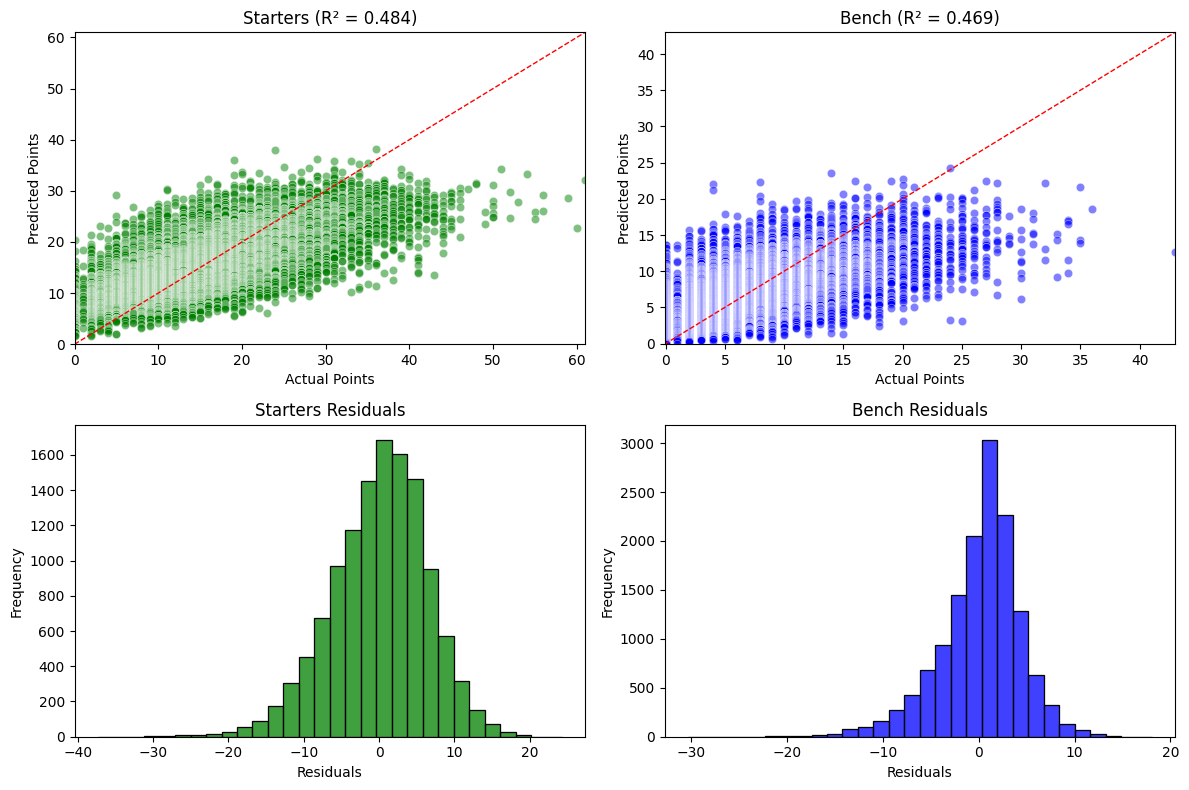

In [ ]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]
starters_r2 = r2_score(starters['actual'], starters['predicted'])
bench_r2 = r2_score(bench['actual'], bench['predicted'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


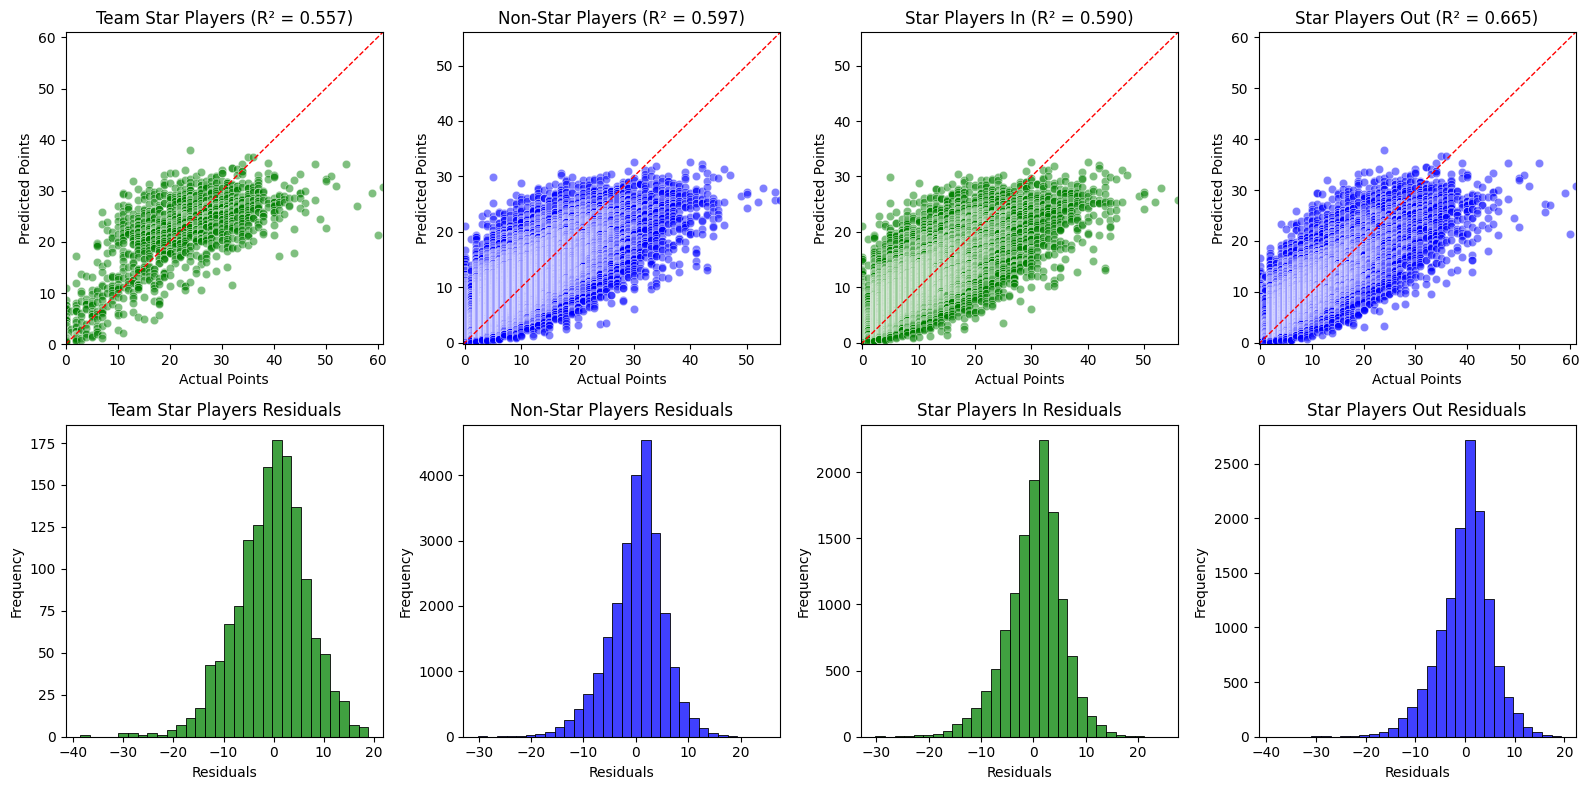

In [ ]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]
star_r2 = r2_score(starPlayers['actual'], starPlayers['predicted'])
nonStar_r2 = r2_score(nonStarPlayers['actual'], nonStarPlayers['predicted'])

starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]
starsIn_r2 = r2_score(starsIn['actual'], starsIn['predicted'])
starsOut_r2 = r2_score(starsOut['actual'], starsOut['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Team Star Players
sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Team Star Players (R² = {star_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Non-Star Players
sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Non-Star Players (R² = {nonStar_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Star Players In
sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'Star Players In (R² = {starsIn_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Star Players Out
sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Star Players Out (R² = {starsOut_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Team Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('Star Players In Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Star Players Out Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

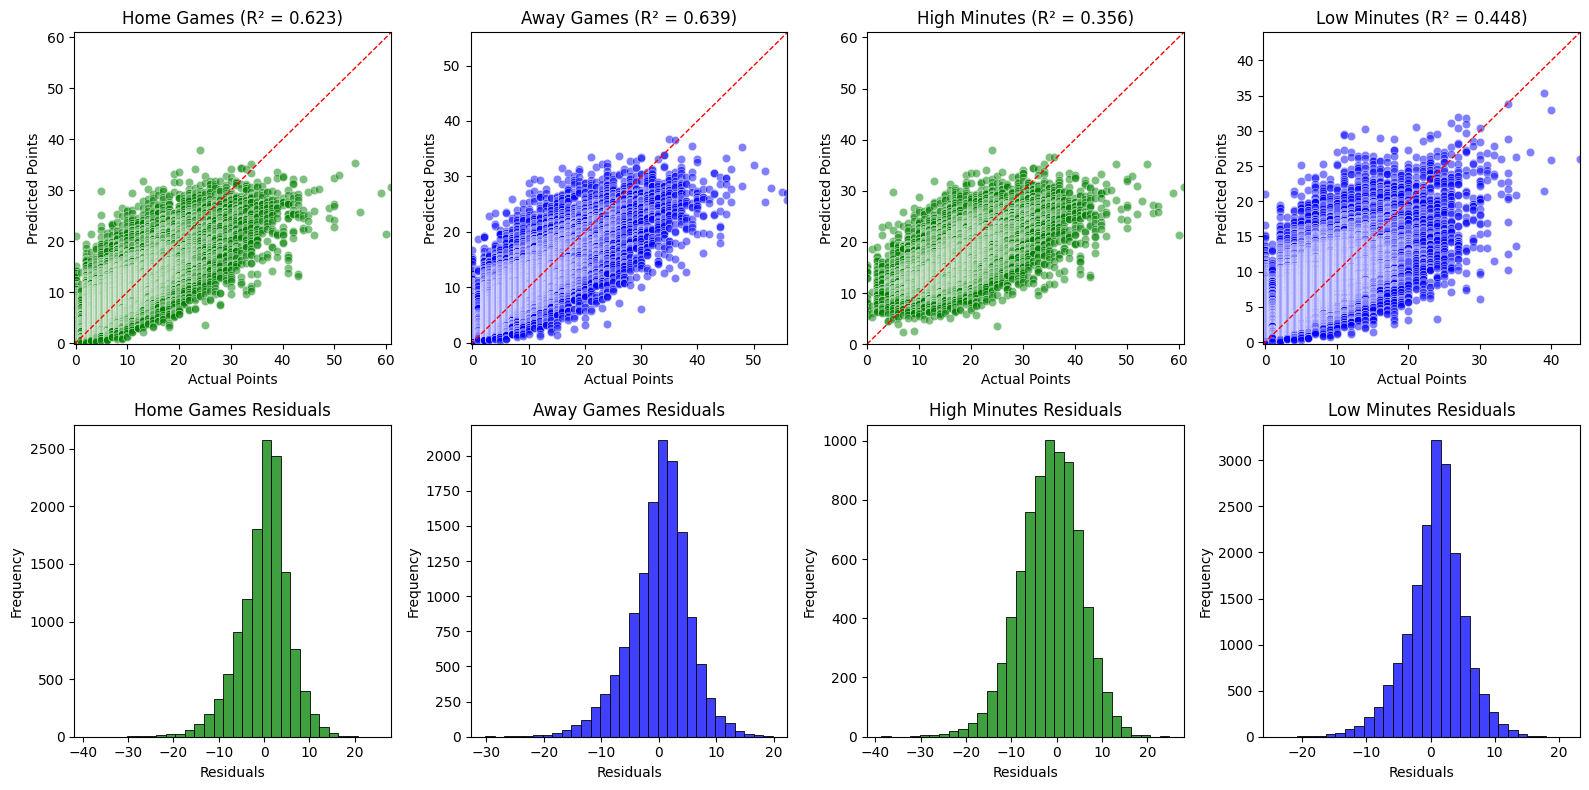

In [ ]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]
homeGames_r2 = r2_score(homeGames['actual'], homeGames['predicted'])
awayGames_r2 = r2_score(awayGames['actual'], awayGames['predicted'])

highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]
highMins_r2 = r2_score(highMins['actual'], highMins['predicted'])
lowMins_r2 = r2_score(lowMins['actual'], lowMins['predicted'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  

# Home Games
sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Home Games (R² = {homeGames_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Away Games
sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Away Games (R² = {awayGames_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# High Minutes
sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,2])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,2].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,2].set_xlim(minVal, maxVal)
axes[0,2].set_ylim(minVal, maxVal)
axes[0,2].set_title(f'High Minutes (R² = {highMins_r2:.3f})')
axes[0,2].set_xlabel('Actual Points')
axes[0,2].set_ylabel('Predicted Points')

# Low Minutes
sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,3])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,3].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,3].set_xlim(minVal, maxVal)
axes[0,3].set_ylim(minVal, maxVal)
axes[0,3].set_title(f'Low Minutes (R² = {lowMins_r2:.3f})')
axes[0,3].set_xlabel('Actual Points')
axes[0,3].set_ylabel('Predicted Points')

# Residual histograms
sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,2])
axes[1,2].set_title('High Minutes Residuals')
axes[1,2].set_xlabel('Residuals')
axes[1,2].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,3])
axes[1,3].set_title('Low Minutes Residuals')
axes[1,3].set_xlabel('Residuals')
axes[1,3].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()